In [4]:
import sys
sys.path.append(r"C:\ddddwoo\project\HotelBear")
from BackEnd.database import get_connection
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import tqdm 
import re

In [5]:
def load_data():
    conn = get_connection()
    with conn.cursor() as cursor:
                cursor.execute("SELECT * FROM onlyhotellist")
                rows = cursor.fetchall()  # DictCursor라서: 리스트[딕셔너리, ...]
    df = pd.DataFrame(rows)  
    cursor.close()
    conn.close()
    return df

In [6]:
df = load_data()
# display(df.head())

RuntimeError: 'cryptography' package is required for sha256_password or caching_sha2_password auth methods

In [61]:
# 가격 2개 셀
df['facility_count'] = df['facillity_list'].apply(lambda x: len(x.split(','))if isinstance(x, str) else 0)

df = pd.get_dummies(df, columns=['area', 'type'], prefix=['area', 'type'])

id_cols = [col for col in df.columns if col not in ['low_week_price', 'low_weekend_price', 'event_price', 'name', 'facillity_list']]

df_melted = pd.melt(
    df, 
    id_vars=id_cols, 
    value_vars=['low_week_price', 'low_weekend_price'],
    var_name='price_type', 
    value_name='target_price'
)

price_map = {'low_week_price': 0, 'low_weekend_price': 1}
df_melted['day_feature'] = df_melted['price_type'].map(price_map)

df_melted['log_target_price'] = np.log1p(df_melted['target_price'])

final_df = df_melted.drop(columns=['price_type', 'target_price'])

print(f"전처리 전 데이터 개수: {len(df)}개")
print(f"전처리 후 데이터 개수: {len(final_df)}개 (2배 증폭 완료)")
print("\n--- 최종 데이터 컬럼 구성 ---")
print(final_df.columns.tolist())

전처리 전 데이터 개수: 904개
전처리 후 데이터 개수: 1808개 (2배 증폭 완료)

--- 최종 데이터 컬럼 구성 ---
['id', 'grade', 'reviewCount', 'swimming_pool', 'breakfast', 'bathtub', 'pickUp', 'fitness', 'bar', 'desk24', 'terrace', 'club', 'parking', 'address', 'img_url', 'star', 'facility_count', 'area_101', 'area_102', 'area_103', 'area_104', 'area_105', 'area_106', 'area_107', 'area_108', 'area_109', 'area_110', 'area_111', 'type_100', 'type_500', 'day_feature', 'log_target_price']


In [70]:
# 가격 3개 셀셀
df['facility_count'] = df['facillity_list'].apply(lambda x: len(x.split(','))if isinstance(x, str) else 0)

df = pd.get_dummies(df, columns=['area', 'type'], prefix=['area', 'type'])

id_cols = [col for col in df.columns if col not in ['low_week_price', 'low_weekend_price', 'event_price', 'name', 'facillity_list']]

df_melted = pd.melt(
    df, 
    id_vars=id_cols, 
    value_vars=['low_week_price', 'low_weekend_price', 'event_price'],
    var_name='price_type', 
    value_name='target_price'
)

price_map = {'low_week_price': 0, 'low_weekend_price': 1, 'event_price': 2}
df_melted['day_feature'] = df_melted['price_type'].map(price_map)

df_melted['log_target_price'] = np.log1p(df_melted['target_price'])

final_df = df_melted.drop(columns=['price_type', 'target_price'])

print(f"전처리 전 데이터 개수: {len(df)}개")
print(f"전처리 후 데이터 개수: {len(final_df)}개 (3배 증폭 완료)")
print("\n--- 최종 데이터 컬럼 구성 ---")
print(final_df.columns.tolist())

KeyError: "None of [Index(['area', 'type'], dtype='str')] are in the [columns]"

In [ ]:
geolocator = Nominatim(user_agent="hotel_price_predictor", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 주소 특수기호 정리리
def clean_address(address):
    return re.sub(r'\([^)]*\)', '', address).strip()

# 2. 좌표를 가져오는 함수 정의
def get_coordinates(address):
    # 1단계: 주소 정제 (괄호 제거)
    cleaned_addr = clean_address(address)
    
    try:
        location = geocode(cleaned_addr)
        if location:
            return location.latitude, location.longitude
        
        short_addr = " ".join(cleaned_addr.split()[:3])
        location = geocode(short_addr)
        if location:
            return location.latitude, location.longitude
            
        return None, None
    except Exception as e:
        print(f"⚠️ 에러 발생: {e}")
        return None, None

print("📍 주소를 좌표로 변환 중입니다... (잠시만 기다려주세요)")

# 중복된 주소만 따로 뽑아서 변환하면 시간을 훨씬 아낄 수 있습니다.
unique_addresses = final_df['address'].unique()
address_map = {}
for addr in unique_addresses:
    lat, lon = get_coordinates(addr)
    address_map[addr] = {'lat': lat, 'lon': lon}


final_df['latitude'] = final_df['address'].map(lambda x: address_map[x]['lat'])
final_df['longitude'] = final_df['address'].map(lambda x: address_map[x]['lon'])

final_df = final_df.dropna(subset=['latitude', 'longitude'])

print(f"✅ 변환 완료! 현재 데이터 개수: {len(final_df)}개")

📍 주소를 좌표로 변환 중입니다... (잠시만 기다려주세요)


In [ ]:
from haversine import haversine
import matplotlib.pyplot as plt
import seaborn as sns


center_lat = final_df['latitude'].mean()
center_lon = final_df['longitude'].mean()
center_loc = (center_lat, center_lon)

def calculate_distance(row):
    hotel_loc = (row['latitude'], row['longitude'])
    # 단위: km (미터로 하려면 * 1000)
    return haversine(center_loc, hotel_loc)

# 중심점에서 각 호텔까지의 거리 (km)
final_df['dist_to_center'] = final_df.apply(calculate_distance, axis=1)

# 중심점에서 각 호텔 방향(각도 0~360°, 북=0, 시계방향) → 지역 효과 반영용
def bearing_from_center(center_lat, center_lon, lat, lon):
    lat1, lon1 = np.radians(center_lat), np.radians(center_lon)
    lat2, lon2 = np.radians(lat), np.radians(lon)
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    angle = np.degrees(np.arctan2(x, y))
    return (angle + 360) % 360

final_df['angle_from_center'] = final_df.apply(
    lambda row: bearing_from_center(center_lat, center_lon, row['latitude'], row['longitude']),
    axis=1
)
# sin/cos로 넣으면 0°와 360°가 이어져서 모델이 방향을 더 잘 씀
final_df['angle_sin'] = np.sin(np.radians(final_df['angle_from_center']))
final_df['angle_cos'] = np.cos(np.radians(final_df['angle_from_center']))

# 1-2. 데이터 정제 (학습에 방해되는 텍스트 컬럼 제거)
# id, address, img_url 등은 숫자가 아니므로 모델이 읽지 못합니다.
# angle_from_center는 angle_sin, angle_cos로 이미 반영되므로 제거
features_to_drop = ['id', 'address', 'img_url', 'latitude', 'longitude', 'angle_from_center']
study_df = final_df.drop(columns=features_to_drop)

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# 2-1. 데이터 분리 (문제와 정답)
X = study_df.drop(columns=['log_target_price']) # 문제집
y = study_df['log_target_price'] # 정답지

# 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=2026)

# 2-2. 3가지 강력한 모델 정의
model1 = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=2026
    )
model2 = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=2026
    )
model3 = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_strength=1.5,
    bagging_temperature=1,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=2026,
    verbose=200 
)

# 2-3. 앙상블 모델 구성 (Voting)
ensemble_model = VotingRegressor(
    estimators=[
        ('xgb', model1), 
        ('lgbm', model2), 
        ('CBR', model3)
    ]
)

# 2-4. 학습 시작
print("🚀 앙상블 모델 학습 중...")
ensemble_model.fit(X_train, y_train)

# 2-5. 평가
y_pred_log = ensemble_model.predict(X_test)
# 로그를 다시 원래 가격으로 복구 (np.expm1)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred_log)

print(f"\n📊 모델 평가 결과")
print(f"평균 절대 오차(MAE): 약 {int(mae):,}원")
print(f"결정계수(R2 Score): {r2:.4f} (1에 가까울수록 완벽)")

🚀 앙상블 모델 학습 중...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 616
[LightGBM] [Info] Number of data points in the train set: 1573, number of used features: 28
[LightGBM] [Info] Start training from score 11.714718
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

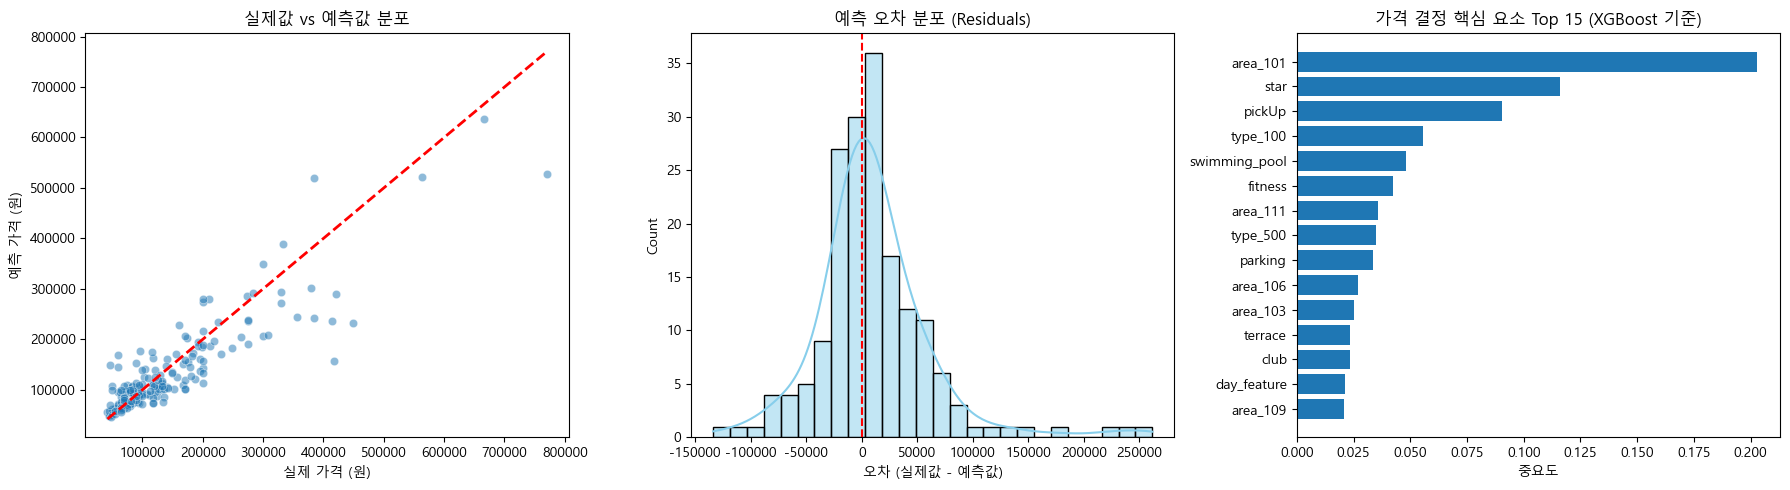

In [66]:
# 1. 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic' 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(18, 5))

# --- [그래프 1] 실제값 vs 예측값 (Scatter Plot) ---
# 모델이 얼마나 정답에 가깝게 예측했는지 점을 찍어보는 거예요.
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.5)
# 완벽한 정답선(대각선) 그리기
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel('실제 가격 (원)')
plt.ylabel('예측 가격 (원)')
plt.title('실제값 vs 예측값 분포')

# --- [그래프 2] 오차 분포 (Residual Plot) ---
# 모델이 주로 얼마만큼의 오차를 내는지 확인합니다. 0 근처에 몰려있을수록 좋아요.
plt.subplot(1, 3, 2)
error = y_test_real - y_pred_real
sns.histplot(error, kde=True, color='skyblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('오차 (실제값 - 예측값)')
plt.title('예측 오차 분포 (Residuals)')

# --- [그래프 3] 변수 중요도 (Feature Importance) ---
# 앙상블 모델 중 XGBoost 모델을 기준으로 "어떤 데이터가 가격에 가장 큰 영향을 줬는지" 확인합니다.
plt.subplot(1, 3, 3)
# 앙상블 내의 첫 번째 모델(XGBoost)의 중요도 추출
importances = ensemble_model.estimators_[0].feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:] # 상위 15개만

plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('중요도')
plt.title('가격 결정 핵심 요소 Top 15 (XGBoost 기준)')

plt.tight_layout()
plt.show()

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# 2-1. 데이터 분리
X = study_df.drop(columns=['log_target_price'])
y = study_df['log_target_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=2026)

# 2-2. CatBoost 단일 모델
model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_strength=1.5,
    bagging_temperature=1,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=2026,
    verbose=200
)

# 2-3. 학습 (VotingRegressor 없이 model만 사용)
print("🚀 CatBoost 모델 학습 중...")
model.fit(X_train, y_train)

# 2-4. 예측 및 평가
y_pred_log = model.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred_log)

print(f"\n📊 모델 평가 결과")
print(f"평균 절대 오차(MAE): 약 {int(mae):,}원")
print(f"결정계수(R2 Score): {r2:.4f} (1에 가까울수록 완벽)")

🚀 CatBoost 모델 학습 중...
0:	learn: 0.6068919	total: 1.98ms	remaining: 9.9s
200:	learn: 0.3719347	total: 257ms	remaining: 6.13s
400:	learn: 0.3193273	total: 480ms	remaining: 5.5s
600:	learn: 0.2795085	total: 699ms	remaining: 5.11s
800:	learn: 0.2510475	total: 919ms	remaining: 4.82s
1000:	learn: 0.2287790	total: 1.16s	remaining: 4.63s
1200:	learn: 0.2104545	total: 1.39s	remaining: 4.41s
1400:	learn: 0.1949073	total: 1.62s	remaining: 4.17s
1600:	learn: 0.1816828	total: 1.84s	remaining: 3.91s
1800:	learn: 0.1697020	total: 2.08s	remaining: 3.7s
2000:	learn: 0.1592369	total: 2.31s	remaining: 3.46s
2200:	learn: 0.1495449	total: 2.55s	remaining: 3.24s
2400:	learn: 0.1417365	total: 2.78s	remaining: 3.01s
2600:	learn: 0.1347302	total: 3s	remaining: 2.77s
2800:	learn: 0.1281863	total: 3.23s	remaining: 2.54s
3000:	learn: 0.1224240	total: 3.46s	remaining: 2.31s
3200:	learn: 0.1171814	total: 3.7s	remaining: 2.08s
3400:	learn: 0.1120959	total: 3.94s	remaining: 1.85s
3600:	learn: 0.1075606	total: 4.17s	r

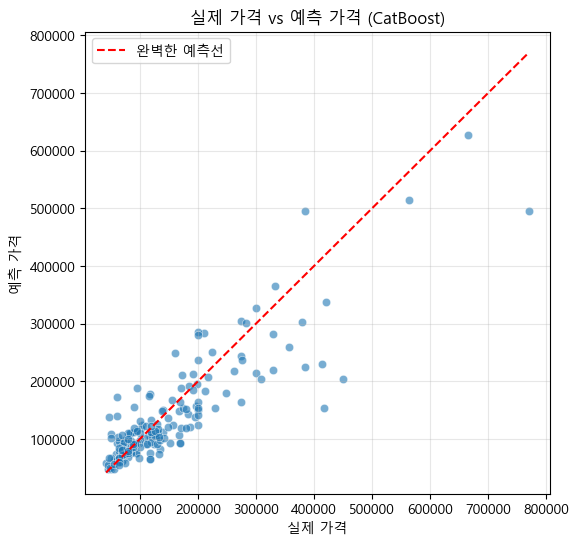

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.6)
max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='완벽한 예측선')

plt.xlabel("실제 가격")
plt.ylabel("예측 가격")
plt.title("실제 가격 vs 예측 가격 (CatBoost)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()